In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df = pd.read_csv("/content/Day14_Food_Delivery_Visualization_Dataset.csv")

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day"] = pd.Categorical(df["Day"], categories=day_order, ordered=True)

print("Shape:", df.shape)
df.head()

Shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


In [22]:
df.describe()

,Date,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
count,360,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,2025-06-30 21:31:59.999999744,147.647222,409.151083,60591.114778,27161.430028,5753.397000,32.577500,4.452861,41.600000
min,2025-01-02 00:00:00,58.000000,243.760000,20618.530000,11336.640000,1219.310000,20.600000,3.810000,24.800000
25%,2025-04-05 12:00:00,123.750000,353.840000,48400.832500,21822.500000,3566.615000,28.675000,4.310000,37.900000
50%,2025-06-26 12:00:00,147.000000,412.410000,58779.190000,25874.140000,5226.870000,32.000000,4.470000,41.900000
75%,2025-09-25 12:00:00,169.000000,464.945000,71740.142500,32387.137500,7610.367500,35.950000,4.610000,45.225000
max,2025-12-28 00:00:00,235.000000,575.940000,121381.980000,45000.000000,15000.000000,50.100000,4.940000,54.000000
std,NaN,33.387161,70.249186,17387.926132,6970.558278,2647.410844,5.281562,0.209699,5.336472


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    category      
 3   Day                      360 non-null    category      
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                360 non-nul

In [24]:
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)

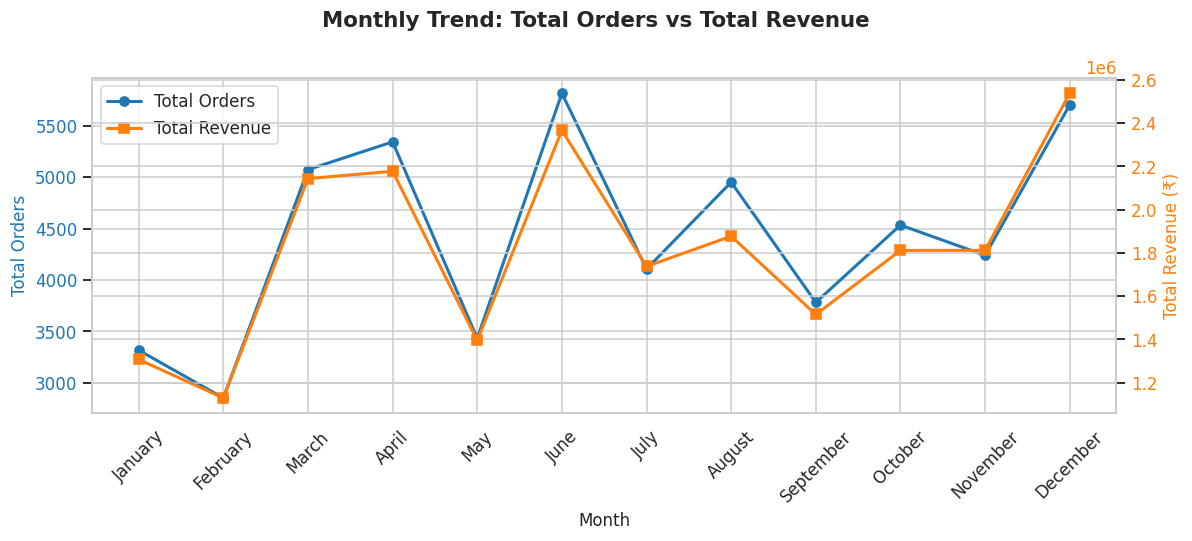

In [25]:
monthly = df.groupby("Month", observed=True).agg(
    Total_Orders=("Orders", "sum"),
    Total_Revenue=("Revenue", "sum")
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))

color1 = "tab:blue"
ax1.plot(monthly["Month"], monthly["Total_Orders"], marker="o", color=color1, linewidth=2, label="Total Orders")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Orders", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(monthly["Month"], monthly["Total_Revenue"], marker="s", color=color2, linewidth=2, label="Total Revenue")
ax2.set_ylabel("Total Revenue (₹)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle("Monthly Trend: Total Orders vs Total Revenue", fontsize=14, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

Orders and revenue move closely together across the year, confirming that revenue
is largely order-volume driven rather than being decoupled by pricing changes .
focus shld at the places where ther is divregence in both the lines

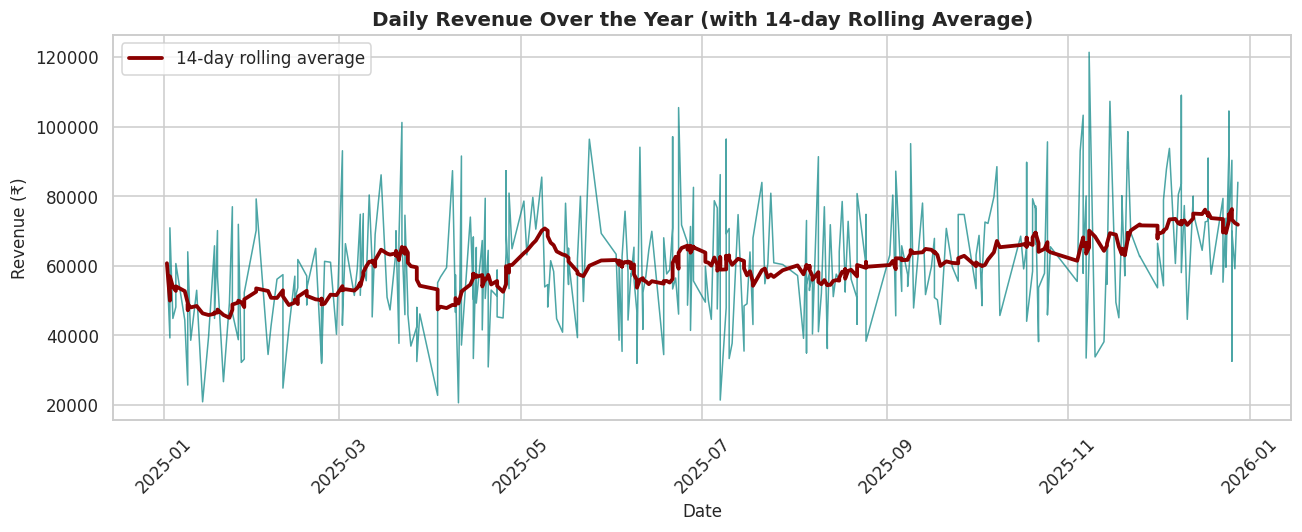

In [26]:
daily = df.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily["Date"], daily["Revenue"], color="teal", linewidth=1, alpha=0.7)
ax.plot(daily["Date"], daily["Revenue"].rolling(14, min_periods=1).mean(),
        color="darkred", linewidth=2.5, label="14-day rolling average")

ax.set_title("Daily Revenue Over the Year (with 14-day Rolling Average)")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (₹)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The raw daily series is noisy, but the rolling average smooths out day-to-day
fluctuations and reveals the underlying revenue trend

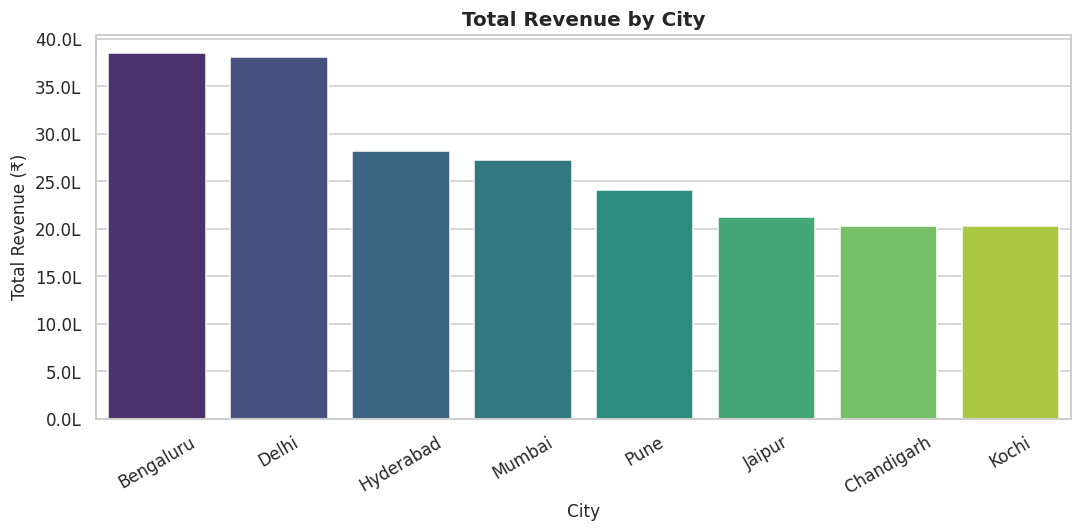

In [27]:
city_revenue = df.groupby("City", observed=True)["Revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values, hue=city_revenue.index,
            palette="viridis", legend=False, ax=ax)
ax.set_title("Total Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Total Revenue (₹)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e5:.1f}L"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

the revenue isnt distributed uniformly between cities

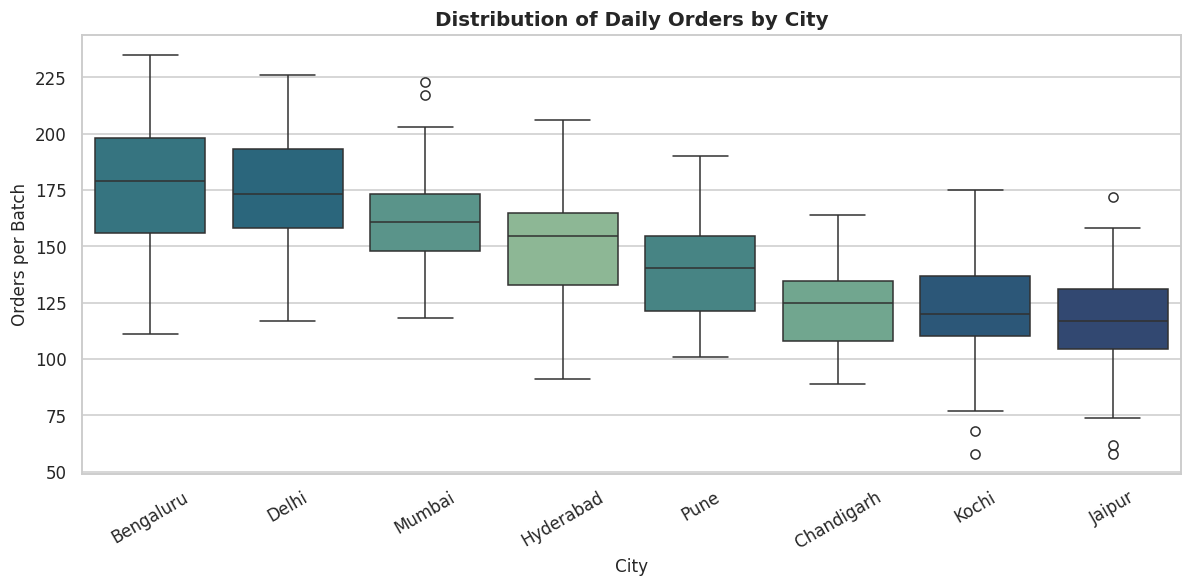

In [28]:
fig, ax = plt.subplots(figsize=(11, 5.5))
order = df.groupby("City", observed=True)["Orders"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="City", y="Orders", order=order, hue="City",
            palette="crest", legend=False, ax=ax)
ax.set_title("Distribution of Daily Orders by City")
ax.set_xlabel("City")
ax.set_ylabel("Orders per Batch")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

the box plot shows both the median order volume and its variability per city.
Cities with a tall box/whiskers have more volatile demand, while tight boxes indicate consistent,
predictable order volumes

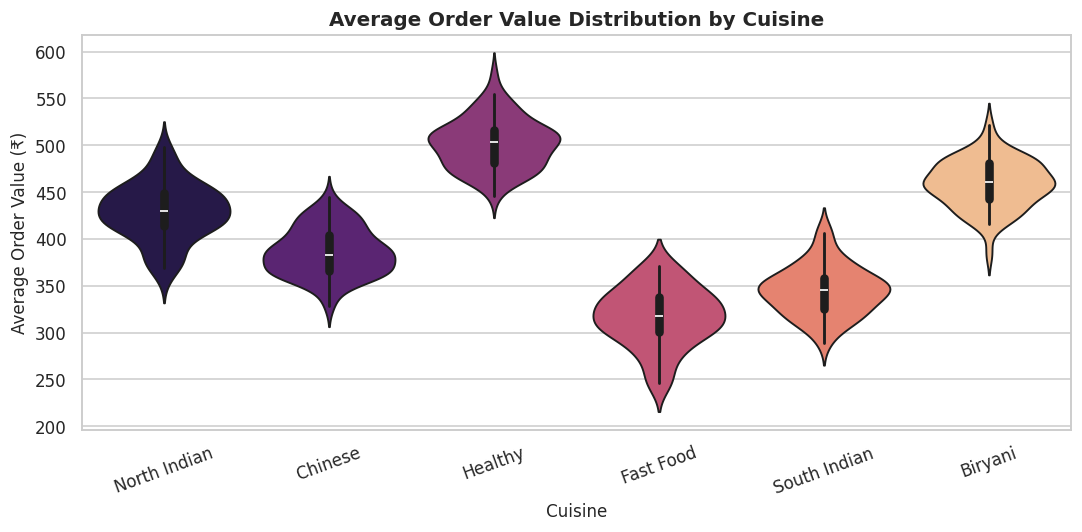

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x="Cuisine", y="Average_Order_Value", hue="Cuisine",
               palette="magma", legend=False, ax=ax)
ax.set_title("Average Order Value Distribution by Cuisine")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Average Order Value (₹)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

the violin plot reveals not just the median order value per cuisine but the full
shape of the distribution

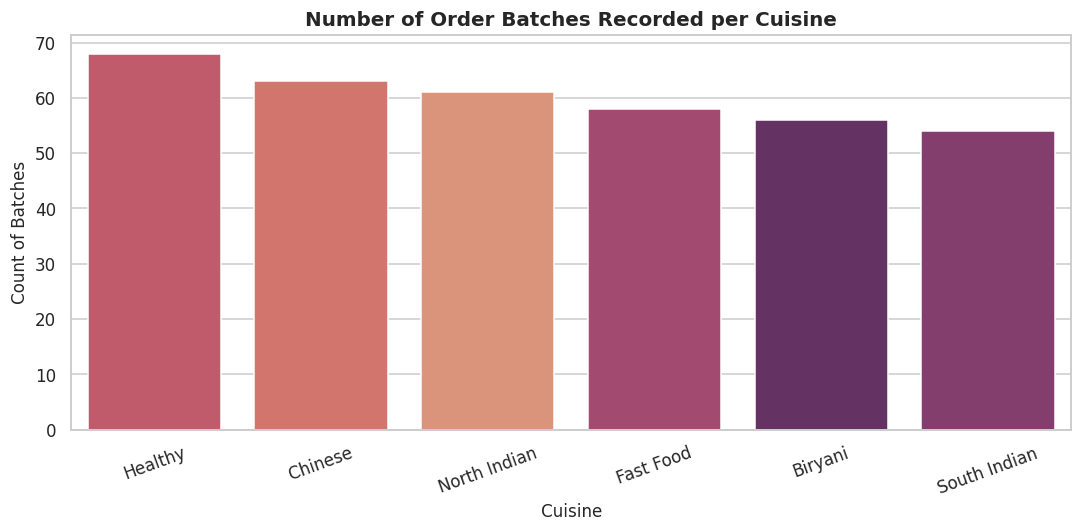

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
cuisine_count_order = df["Cuisine"].value_counts().index
sns.countplot(data=df, x="Cuisine", order=cuisine_count_order, hue="Cuisine",
              palette="flare", legend=False, ax=ax)
ax.set_title("Number of Order Batches Recorded per Cuisine")
ax.set_xlabel("Cuisine")
ax.set_ylabel("Count of Batches")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

count plot shows how frequently each cuisine appears in the dataset, which
reflects how often it was the dominant cuisine for a batch/day

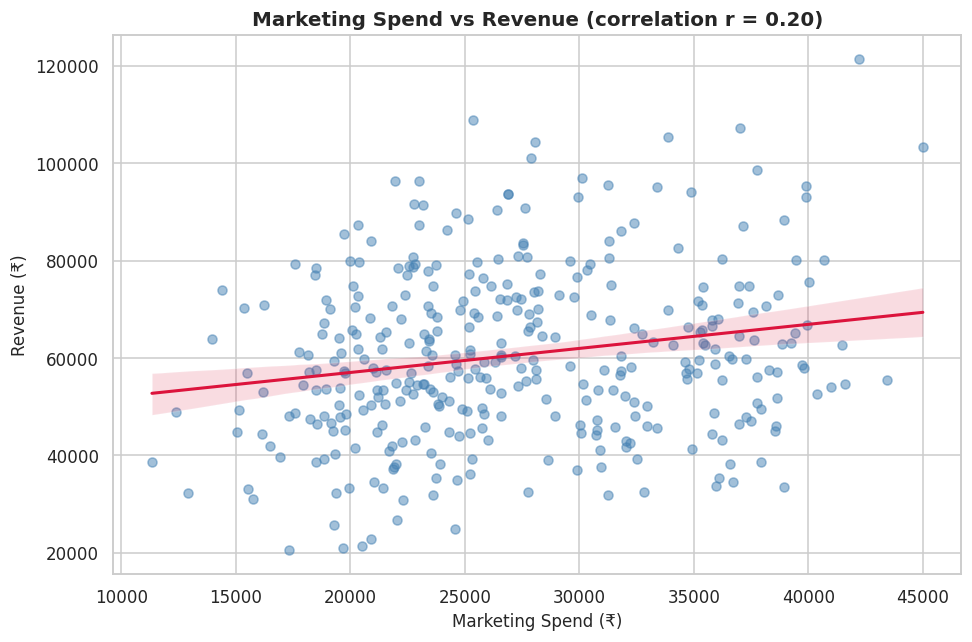

In [31]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df, x="Marketing_Spend", y="Revenue", ax=ax,
            scatter_kws={"alpha": 0.5, "s": 35, "color": "steelblue"},
            line_kws={"color": "crimson", "linewidth": 2})

corr_val = df["Marketing_Spend"].corr(df["Revenue"])
ax.set_title(f"Marketing Spend vs Revenue (correlation r = {corr_val:.2f})")
ax.set_xlabel("Marketing Spend (₹)")
ax.set_ylabel("Revenue (₹)")
plt.tight_layout()
plt.show()

the  scatter plot with fitted regression line shows the direction and strength
of the relationship between marketing spend and revenue directly on the chart. a positive slope
with points hugging the line indicates marketing spend is a reliable revenue driver; a shallow
slope or scattered points would suggest diminishing or inconsistent returns on marketing.

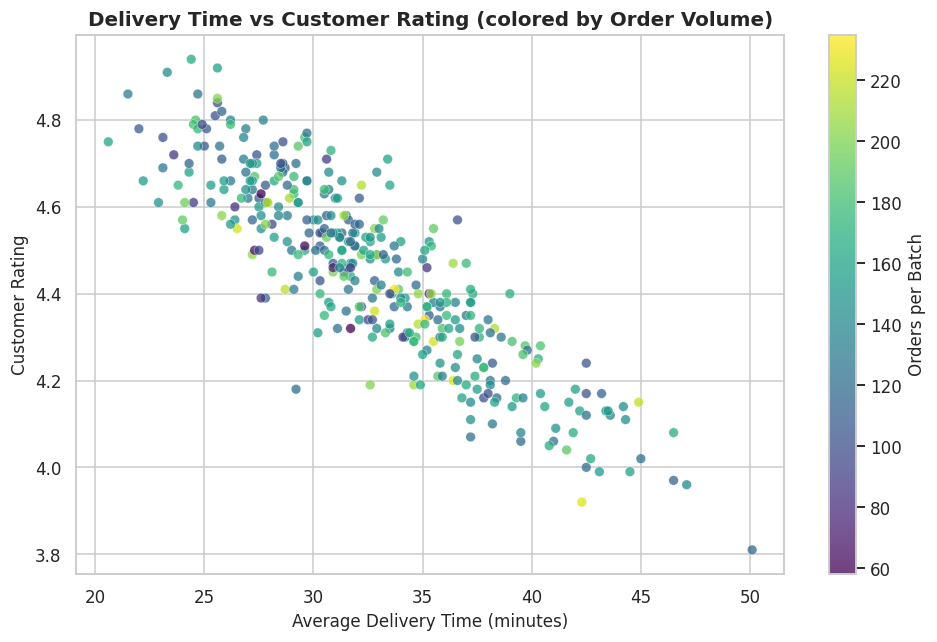

In [32]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df["Avg_Delivery_Minutes"], df["Customer_Rating"],
                      c=df["Orders"], cmap="viridis", alpha=0.75, s=40, edgecolor="white", linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Orders per Batch")

ax.set_title("Delivery Time vs Customer Rating (colored by Order Volume)")
ax.set_xlabel("Average Delivery Time (minutes)")
ax.set_ylabel("Customer Rating")
plt.tight_layout()
plt.show()

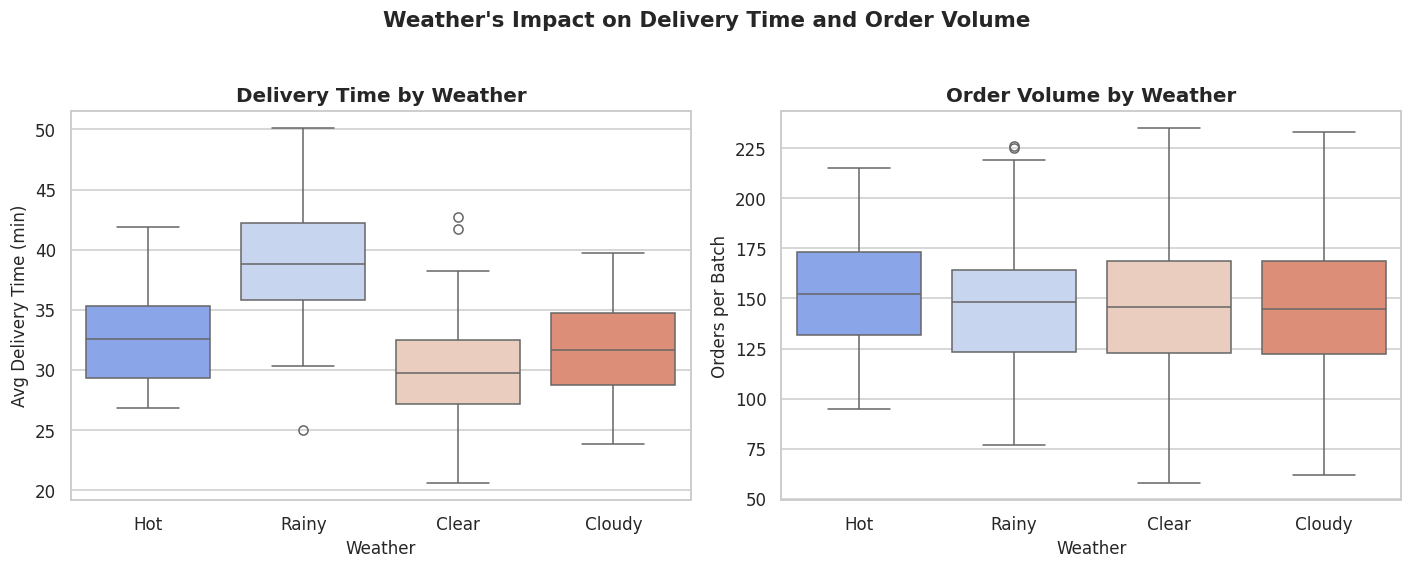

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Weather", y="Avg_Delivery_Minutes", hue="Weather",
            palette="coolwarm", legend=False, ax=axes[0])
axes[0].set_title("Delivery Time by Weather")
axes[0].set_xlabel("Weather")
axes[0].set_ylabel("Avg Delivery Time (min)")

sns.boxplot(data=df, x="Weather", y="Orders", hue="Weather",
            palette="coolwarm", legend=False, ax=axes[1])
axes[1].set_title("Order Volume by Weather")
axes[1].set_xlabel("Weather")
axes[1].set_ylabel("Orders per Batch")

fig.suptitle("Weather's Impact on Delivery Time and Order Volume", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

rainy conditions tend to push delivery times up (traffic, safety-driven slower
driving) while sometimes also boosting order volume (people ordering in rather than going out).
clear/Hot conditions typically show faster, more predictable deliveries. together the two panels
tell a coherent story: bad weather is a double-edged sword

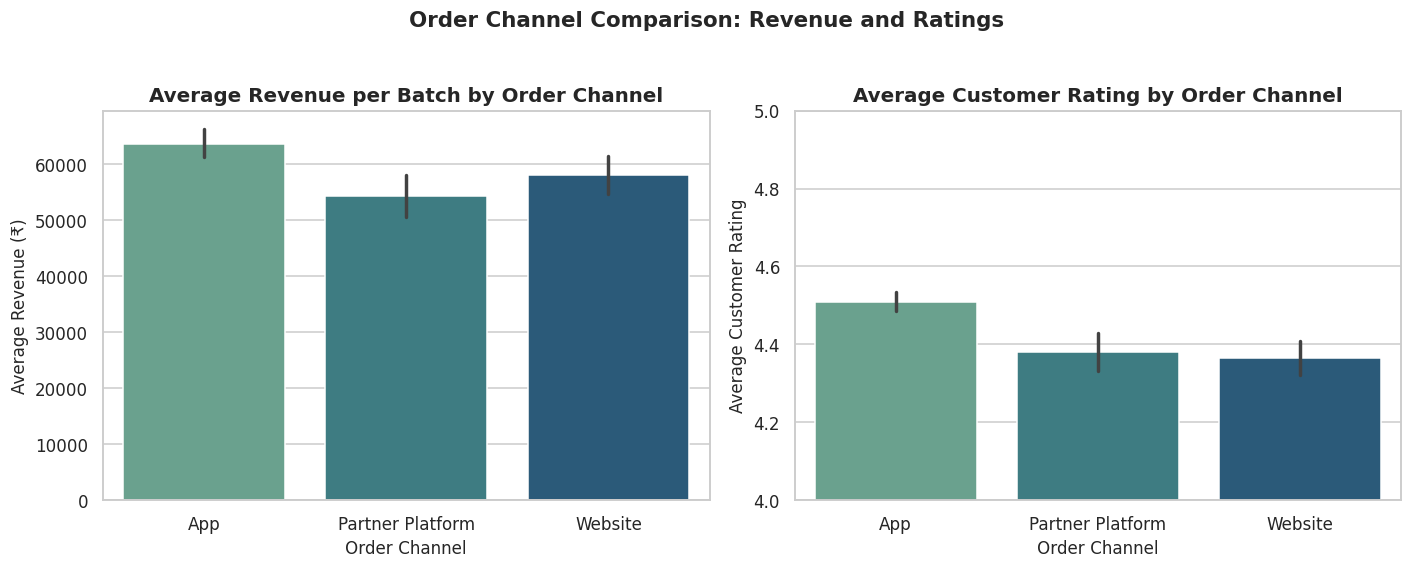

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=df, x="Order_Channel", y="Revenue", hue="Order_Channel", estimator=np.mean,
            palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Average Revenue per Batch by Order Channel")
axes[0].set_xlabel("Order Channel")
axes[0].set_ylabel("Average Revenue (₹)")

sns.barplot(data=df, x="Order_Channel", y="Customer_Rating", hue="Order_Channel", estimator=np.mean,
            palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Average Customer Rating by Order Channel")
axes[1].set_xlabel("Order Channel")
axes[1].set_ylabel("Average Customer Rating")
axes[1].set_ylim(4.0, 5.0)

fig.suptitle("Order Channel Comparison: Revenue and Ratings", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

comparing average revenue and average rating side-by-side by channel highlights
whether the highest-revenue channel is also the highest-satisfaction channel, or whether there's
a trade-off

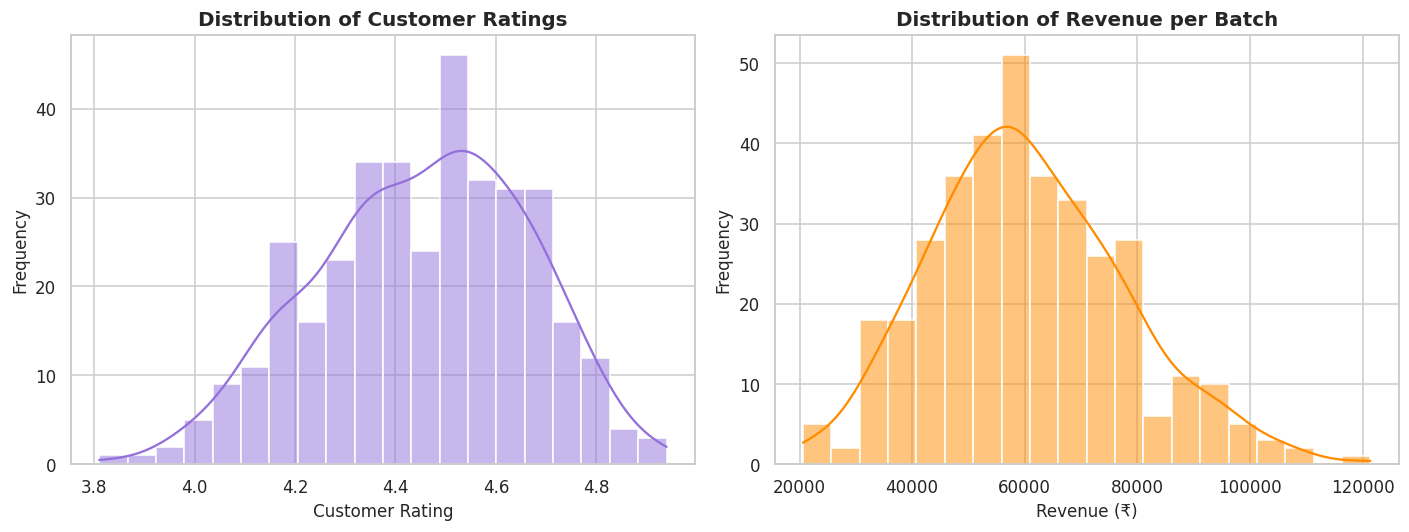

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Customer_Rating"], bins=20, kde=True, color="mediumpurple", ax=axes[0])
axes[0].set_title("Distribution of Customer Ratings")
axes[0].set_xlabel("Customer Rating")
axes[0].set_ylabel("Frequency")

sns.histplot(df["Revenue"], bins=20, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Distribution of Revenue per Batch")
axes[1].set_xlabel("Revenue (₹)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

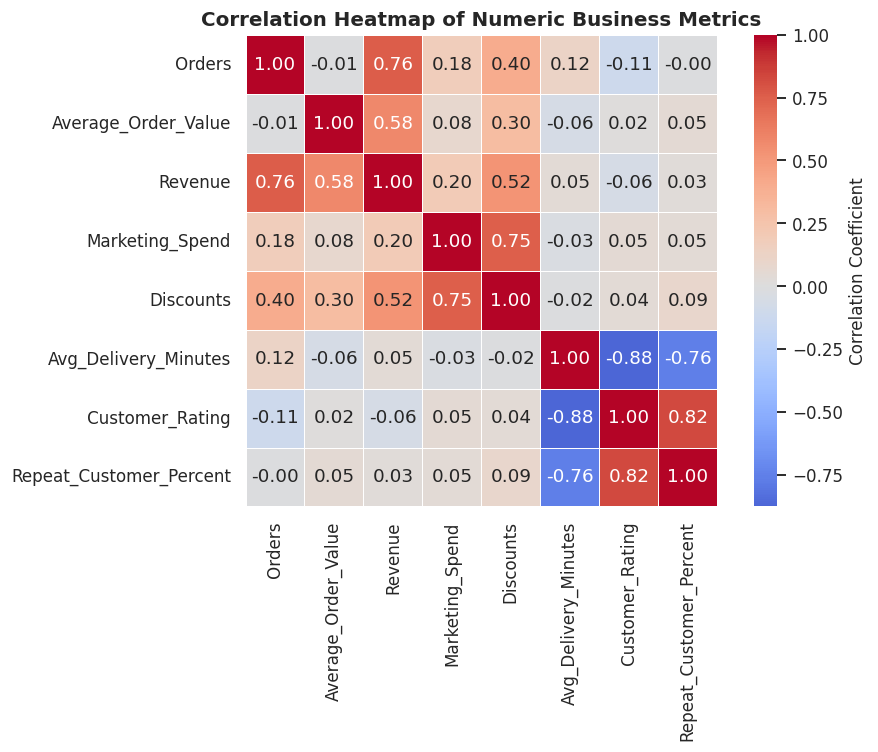

In [36]:
numeric_cols = ["Orders", "Average_Order_Value", "Revenue", "Marketing_Spend",
                 "Discounts", "Avg_Delivery_Minutes", "Customer_Rating", "Repeat_Customer_Percent"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Correlation Coefficient"}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Business Metrics")
plt.tight_layout()
plt.show()

the heatmap consolidates every pairwise relationship at a glance. the strongest
positive correlation is expected between **Orders** and **Revenue**. a negative correlation
between **Avg_Delivery_Minutes** and **Customer_Rating** would confirm the pattern seen earlier
in the scatter plot, while the correlation (or lack thereof) between **Marketing_Spend** and
**Repeat_Customer_Percent** indicates whether marketing spend builds loyalty or just drives
one-off orders.